In [9]:
#this script is for cleaning the raw data of the lseg coffee prices into what we use

# openpyxl: third-party library for reading/writing Excel files (.xlsx). Python
# can't open .xlsx on its own (it's a zipped bundle of XML), so openpyxl does it.
# Here it's used only to READ the raw Excel file. Install once: pip install openpyxl
import openpyxl
# csv: Python's built-in module for reading/writing CSV (comma-separated) files.
# Ships with Python, nothing to install. Here it WRITES the cleaned data out as CSV.
import csv

raw = openpyxl.load_workbook("KCc1 raw daily 1990-2026.xlsx", data_only=True).active

# find row that starts the price history ("Exchange Date" header)
start = next(i for i, r in enumerate(raw.iter_rows(values_only=True), 1)
             if r[0] == "Exchange Date")

# write a clean CSV with just the two columns
with open("KCc1 daily arabica 1990-2026.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Exchange Date", "Close"])
    row = 0
    for date, close, *_ in raw.iter_rows(min_row=start + 1, values_only=True):
        if date is None:                       # skip only fully-blank trailing rows
            continue
        close = round(close, 2) if close is not None else ""   # keep row; blank if no close
        w.writerow([date.strftime("%d-%b-%Y"), close])
        row += 1

print(f"wrote {row} rows")

wrote 9186 rows


In [3]:
import openpyxl
from openpyxl import Workbook

# Load the raw Excel workbook
raw = openpyxl.load_workbook(
    "KCc1 monthly arabica 2000-2025 raw.xlsx",
    data_only=True
).active

# Find the row containing the "Exchange Date" header
start = next(
    i for i, r in enumerate(raw.iter_rows(values_only=True), 1)
    if r[0] == "Exchange Date"
)

# Create a new Excel workbook
wb = Workbook()
ws = wb.active
ws.title = "Coffee Prices"

# Write column headers
ws.append(["Exchange Date", "Close"])

row_count = 0

# Copy cleaned data
for date, close, *_ in raw.iter_rows(
    min_row=start + 1,
    values_only=True
):
    
    # Skip fully blank trailing rows
    if date is None:
        continue

    # Round close price to 2 decimal places
    close = round(close, 2) if close is not None else None

    # Write actual Excel date rather than text
    ws.append([date, close])

    row_count += 1


# Format the date column as DD-MMM-YYYY
for cell in ws["A"][1:]:
    cell.number_format = "DD-MMM-YYYY"

# Format Close to 2 decimal places
for cell in ws["B"][1:]:
    cell.number_format = "0.00"


ws.column_dimensions["A"].width = 18
ws.column_dimensions["B"].width = 12


# Save as XLSX
output_file = "KCc1 arabica monthly 2000-2025.xlsx"

wb.save(output_file)

print(f"Wrote {row_count} rows to {output_file}")

Wrote 312 rows to KCc1 arabica monthly 2000-2025.xlsx


Country_Name   Brazil  Colombia  Vietnam  Indonesia
Market_Year                                        
2016          56100.0   14600.0  26700.0    10600.0
2017          52100.0   13825.0  29300.0    10400.0
2018          66500.0   13870.0  30400.0    10600.0
2019          60500.0   14100.0  31300.0    10700.0
2020          69900.0   13400.0  29000.0    10700.0
2021          58100.0   11800.0  31580.0    10580.0
2022          62600.0   10700.0  28300.0    10700.0
2023          66300.0   12760.0  27550.0     8150.0
2024          65000.0   14800.0  29000.0    10700.0
2025          63000.0   13800.0  30800.0    12450.0

peaks:
  Brazil: 69,900 in 2020
  Colombia: 17,980 in 1991
  Vietnam: 31,580 in 2021
  Indonesia: 12,450 in 2025


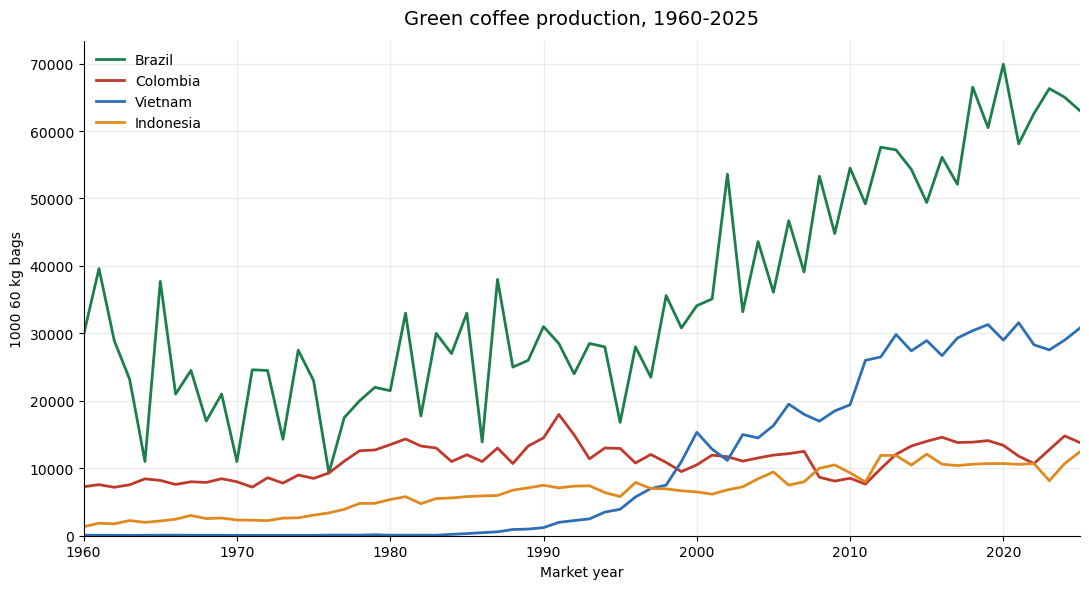

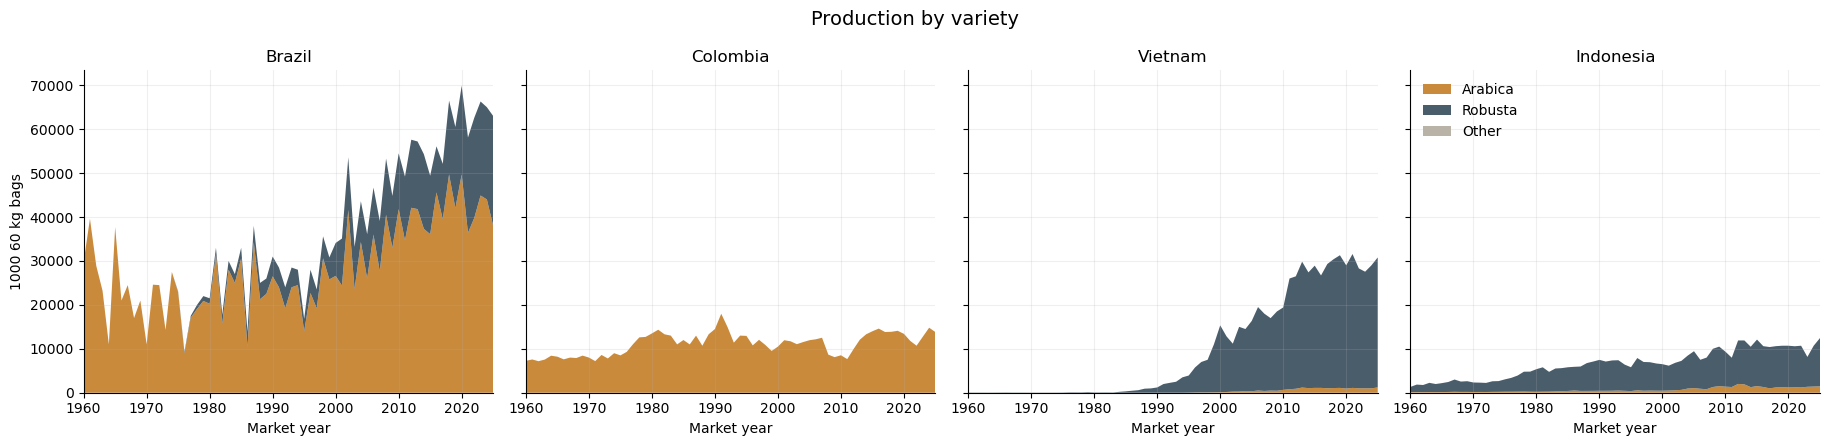

In [1]:
"""
Filter the USDA PSD coffee database to green-coffee production for
Brazil, Colombia, Vietnam and Indonesia, 1960-2025, and plot it.
Units throughout: thousand 60 kg bags.
"""
import pandas as pd
import matplotlib.pyplot as plt

CSV = "whole coffee database.csv"
OUT = "."

COUNTRIES = ["Brazil", "Colombia", "Vietnam", "Indonesia"]
START, END = 1960, 2025
COLORS = {
    "Brazil": "#1b7f4b",
    "Colombia": "#c0392b",
    "Vietnam": "#2c6fb5",
    "Indonesia": "#e08a1e",
}

# load
df = pd.read_csv(CSV)


mask = (
    df["Country_Name"].isin(COUNTRIES)
    & df["Market_Year"].between(START, END)
)
coffee = df.loc[mask]

#  filter

total = (
    coffee[coffee["Attribute_Description"] == "Production"]
    .pivot_table(index="Market_Year", columns="Country_Name", values="Value")
    .reindex(columns=COUNTRIES)
)

varieties = ["Arabica Production", "Robusta Production", "Other Production"]
by_variety = (
    coffee[coffee["Attribute_Description"].isin(varieties)]
    .pivot_table(
        index="Market_Year",
        columns=["Country_Name", "Attribute_Description"],
        values="Value",
    )
)

total.to_csv(f"{OUT}/production_total.csv")
by_variety.to_csv(f"{OUT}/production_by_variety.csv")

# plot 1
fig, ax = plt.subplots(figsize=(11, 6))
for c in COUNTRIES:
    ax.plot(total.index, total[c], label=c, color=COLORS[c], linewidth=2)

ax.set_title(f"Green coffee production, {START}-{END}", fontsize=14, pad=12)
ax.set_ylabel("1000 60 kg bags")
ax.set_xlabel("Market year")
ax.set_xlim(START, END)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{OUT}/production_lines.png", dpi=150)

#  plot 2
# Arabica vs Robusta split
fig, axes = plt.subplots(1, len(COUNTRIES), figsize=(4.6 * len(COUNTRIES), 4.5), sharey=True)
for ax, c in zip(axes, COUNTRIES):
    sub = by_variety[c].reindex(columns=varieties).fillna(0)
    ax.stackplot(
        sub.index,
        sub["Arabica Production"],
        sub["Robusta Production"],
        sub["Other Production"],
        labels=["Arabica", "Robusta", "Other"],
        colors=["#c98a3c", "#4a5d6b", "#b8b2a7"],
    )
    ax.set_title(c)
    ax.set_xlim(START, END)
    ax.set_xlabel("Market year")
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("1000 60 kg bags")
axes[-1].legend(loc="upper left", frameon=False)
fig.suptitle("Production by variety", fontsize=14)
fig.tight_layout()
fig.savefig(f"{OUT}/production_by_variety.png", dpi=150)

# ------------------------------------------------------------- summary
print(total.tail(10).to_string())
print()
print("peaks:")
for c in COUNTRIES:
    print(f"  {c}: {total[c].max():,.0f} in {total[c].idxmax()}")

In [1]:
"""
Plot ICE arabica (KC) front-month price 
"""
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path
UP = Path(".")
FROST_C = 4.5
# load Minas weather 
w = pd.read_csv(UP / "Brazil Minas Gerais 1990-2026.csv", skiprows=15)
w = w[w["T2M_MIN"] > -900].copy()
w["date"] = pd.to_datetime((w["YEAR"] * 1000 + w["DOY"]).astype(str), format="%Y%j")
w = w.sort_values("date")

# load coffee price
kc = pd.read_csv(UP / "KCc1 daily arabica 1990-2026.csv")
kc["date"] = pd.to_datetime(kc["Exchange Date"], format="%d-%b-%Y")
kc = kc[["date", "Close"]].dropna().sort_values("date")
kc["Close"] = kc["Close"].astype(float)

#  events
cold_dates = w.loc[w["T2M_MIN"] <= FROST_C, "date"]
major_frosts = [pd.Timestamp("1994-06-25"), pd.Timestamp("2021-07-01")]
print(f"Cold events (T2M_MIN <= {FROST_C}C): {len(cold_dates)} days")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 11,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linestyle": "-",
    "grid.linewidth": 0.6,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
})
fig, ax = plt.subplots(figsize=(13, 6.2))
# cold-event lines (blue dotted) drawn first; more prominent now
for d in cold_dates:
    ax.axvline(d, color="#1a4de0", linestyle=":", linewidth=0.9, alpha=0.60, zorder=1)
# price line (black)
ax.plot(kc["date"], kc["Close"], color="black", linewidth=0.9, zorder=3)
# major frost lines (red dotted, prominent, no labels)

for d in major_frosts:
    ax.axvline(d, color="red", linestyle=":", linewidth=2.8, alpha=1.0, zorder=2)
# axes cosmetic
ymax = kc["Close"].max()
ax.set_xlabel("Year")
ax.set_ylabel(r"KC front-month price (US\$/lb)")
ax.set_title("ICE Arabica Coffee (KC) Price and Minas Gerais Cold Events, 1990\u20132026")
ax.set_xlim(kc["date"].min(), kc["date"].max())
ax.set_ylim(0, ymax * 1.05)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.margins(x=0)
legend_handles = [
    Line2D([0], [0], color="black", lw=1.0, label="KC arabica front-month"),
    Line2D([0], [0], color="#1a4de0", lw=1.3, ls=":",
           label=r"Cold event (T$_{\mathrm{min}}\leq$ 4.5 $\degree$C)"),
    Line2D([0], [0], color="red", lw=2.8, ls=":",
           label="Major frost (1994, 2021)"),
]
ax.legend(handles=legend_handles, loc="upper left", framealpha=0.95, fontsize=9)
fig.tight_layout()
#save as PDF 
out = "coffee_frost_plot.pdf"
fig.savefig(out)
print("saved", out)

Cold events (T2M_MIN <= 4.5C): 18 days
saved coffee_frost_plot.pdf


In [4]:
"""
Three-month daily plots of KC arabica around the two major Minas Gerais frost
events (Jun-Jul 1994 and Jul 2021), with cold nights marked.

Outputs a vector PDF: text stays selectable, lines stay sharp at any zoom.

"""

import glob
import os

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

#  output config
OUT_PDF = "frost_events_1994_2021.pdf"
OUT_PNG = "frost_events_1994_2021.png"
MAKE_PNG = False


matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.25,
    "font.family": "DejaVu Sans",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
})

# loaders
WX_CANDIDATES = ["Brazil Minas Gerais 1990-2026.csv",
                 "Brazil_Minas_Gerais_1990-2026.csv"]
PX_CANDIDATES = ["KCc1 daily arabica 1990-2026.csv",
                 "KCc1_daily_arabica_1990-2026.csv"]
SEARCH_DIRS = ["."]


def find_file(candidates):
 
    for d in SEARCH_DIRS:
        for name in candidates:
            hits = glob.glob(os.path.join(d, name))
            if hits:
                return hits[0]
    raise FileNotFoundError(
        f"Could not find any of {candidates} in {SEARCH_DIRS}. "
        "Edit SEARCH_DIRS or pass an explicit path."
    )


def load_weather(path=None):
    """NASA POWER daily file: 15 header lines, -999 is the missing-data sentinel."""
    path = path or find_file(WX_CANDIDATES)
    df = pd.read_csv(path, skiprows=15)
    df["date"] = pd.to_datetime(
        df["YEAR"].astype(str) + "-" + df["DOY"].astype(str), format="%Y-%j"
    )
    df = df.replace(-999, np.nan)
    return df[["date", "T2M", "T2M_MIN", "T2M_MAX"]].dropna(subset=["T2M_MIN"])


def load_prices(path=None):
    path = path or find_file(PX_CANDIDATES)
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["Exchange Date"], format="%d-%b-%Y")
    df = df[["date", "Close"]].sort_values("date").drop_duplicates("date")
    return df.reset_index(drop=True)


# events
FROST_LINE = 4.5          # C, grid-mean proxy for damaging frost
COLD_LINE = 8.0           # C, "notably cold night" for context

EVENTS = {
    "1994": {
        "window": ("1994-05-20", "1994-08-20"),
        "frosts": {"1994-06-26": "Frost #1", "1994-07-10": "Frost #2"},
        "title": "1994 double frost",
    },
    "2021": {
        "window": ("2021-06-05", "2021-09-05"),
        "frosts": {"2021-06-30": "Frost #1",
                   "2021-07-20": "Frost #2",
                   "2021-07-30": "Frost #3"},
        "title": "2021 frost sequence",
    },
}


def slice_data(px, wx, window):
    a, b = pd.Timestamp(window[0]), pd.Timestamp(window[1])
    p = px[(px.date >= a) & (px.date <= b)].copy()
    w = wx[(wx.date >= a) & (wx.date <= b)].copy()
    p["ret"] = p["Close"].pct_change()
    return p, w


def panel(axp, axr, axt, p, w, ev):
    frosts = [pd.Timestamp(d) for d in ev["frosts"]]

    # price
    axp.plot(p.date, p.Close, color="#1a1a1a", lw=1.4, zorder=3,
             solid_joinstyle="round")
    axp.scatter(p.date, p.Close, s=6, color="#1a1a1a", zorder=4, linewidths=0)
    lo, hi = p.Close.min(), p.Close.max()
    axp.set_ylim(lo - (hi - lo) * 0.06, hi + (hi - lo) * 0.14)
    for i, (d, lab) in enumerate(ev["frosts"].items()):
        d = pd.Timestamp(d)
        axp.axvline(d, color="#c62828", ls="--", lw=1.0, zorder=2)
        axp.annotate(
            lab, xy=(d, axp.get_ylim()[1]), xytext=(3, -8),
            textcoords="offset points", rotation=90, va="top",
            fontsize=7.5, color="#c62828", fontweight="bold",
        )
    axp.set_ylabel("KC front-month ($/lb)", fontsize=9)
    axp.set_title(
        f"{ev['title']}\n{p.date.iloc[0]:%d %b %Y} \u2013 {p.date.iloc[-1]:%d %b %Y}"
        f"   |   low {lo:.2f}   high {hi:.2f}   (+{hi/lo-1:.0%})",
        fontsize=9.5, fontweight="bold", loc="left", pad=8,
    )
    axp.grid(alpha=0.22, lw=0.5)
    axp.tick_params(labelsize=8)

    # ---- daily returns
    colors = np.where(p.ret >= 0, "#2e7d32", "#c62828")
    axr.bar(p.date, p.ret * 100, color=colors, width=0.9, linewidth=0)
    for d in frosts:
        axr.axvline(d, color="#c62828", ls="--", lw=0.9)
    axr.axhline(0, color="0.3", lw=0.7)
    axr.set_ylabel("daily %", fontsize=9)
    axr.grid(alpha=0.22, lw=0.5)
    axr.tick_params(labelsize=8)

    top = p.loc[p.ret.idxmax()]
    axr.annotate(
        f"{top.ret:+.1%}\n{top.date:%d %b}",
        xy=(top.date, top.ret * 100), xytext=(0, 5),
        textcoords="offset points", ha="center",
        fontsize=7, color="#2e7d32", fontweight="bold",
    )
    axr.set_ylim(top=p.ret.max() * 100 * 1.35)

    # ---- temperature
    axt.plot(w.date, w.T2M_MIN, color="#1565c0", lw=1.1)
    axt.fill_between(w.date, w.T2M_MIN, FROST_LINE,
                     where=w.T2M_MIN < FROST_LINE,
                     color="#1565c0", alpha=0.45, linewidth=0)
    axt.axhline(FROST_LINE, color="#c62828", ls="--", lw=1.0)
    axt.axhline(COLD_LINE, color="#f9a825", ls=":", lw=0.9)
    axt.text(w.date.iloc[1], FROST_LINE + 0.5, f"{FROST_LINE}\u00b0C threshold",
             fontsize=6.5, color="#c62828")
    for d in frosts:
        axt.axvline(d, color="#c62828", ls="--", lw=0.9)
        row = w[w.date == d]
        if not row.empty:
            axt.annotate(
                f"{row.T2M_MIN.iat[0]:.1f}\u00b0C",
                xy=(d, row.T2M_MIN.iat[0]), xytext=(0, -13),
                textcoords="offset points", ha="center",
                fontsize=7, fontweight="bold", color="#c62828",
            )
    axt.set_ylim(bottom=min(0, w.T2M_MIN.min() - 2.5))
    axt.set_ylabel("Min temp (\u00b0C)", fontsize=9)
    axt.grid(alpha=0.22, lw=0.5)
    axt.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    axt.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    axt.tick_params(labelsize=8)


def main():
    px, wx = load_prices(), load_weather()

    
    fig, axes = plt.subplots(
        3, 2, figsize=(13.5, 8.4), sharex="col",
        gridspec_kw={"height_ratios": [2.4, 1, 1.3], "hspace": 0.13, "wspace": 0.17},
    )
    for col, key in enumerate(["1994", "2021"]):
        ev = EVENTS[key]
        p, w = slice_data(px, wx, ev["window"])
        panel(axes[0, col], axes[1, col], axes[2, col], p, w, ev)

    fig.tight_layout()

    fig.savefig(OUT_PDF)                      # vector, no dpi needed
    print(f"saved -> {OUT_PDF}")
    if MAKE_PNG:
        fig.savefig(OUT_PNG, dpi=300)
        print(f"saved -> {OUT_PNG}")

    for key in ["1994", "2021"]:
        ev = EVENTS[key]
        p, _ = slice_data(px, wx, ev["window"])
        first = pd.Timestamp(list(ev["frosts"])[0])
        pre = p[p.date < first].Close.iloc[-1]
        peak, peak_date = p.Close.max(), p.loc[p.Close.idxmax(), "date"]
        print(f"\n{key}: pre-frost close {pre:.2f} -> peak {peak:.2f} "
              f"({peak/pre-1:+.0%}) on {peak_date:%d %b %Y}, "
              f"{(peak_date-first).days} days after first frost")
        print(p.nlargest(5, "ret")[["date", "Close", "ret"]]
              .to_string(index=False, formatters={"ret": lambda x: f"{x:+.1%}"}))


if __name__ == "__main__":
    main()

/var/folders/zz/f4d8ydn15kqfjy20b3p_dqy80000gn/T/ipykernel_45267/4226922575.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved -> frost_events_1994_2021.pdf

1994: pre-frost close 1.26 -> peak 2.46 (+95%) on 12 Jul 1994, 16 days after first frost
      date  Close    ret
1994-06-27   1.60 +27.0%
1994-07-11   2.34 +25.1%
1994-06-29   1.89 +11.2%
1994-06-13   1.38 +10.4%
1994-08-15   1.94  +7.2%

2021: pre-frost close 1.60 -> peak 2.08 (+30%) on 26 Jul 2021, 26 days after first frost
      date  Close    ret
2021-07-22   1.94 +10.2%
2021-07-26   2.08 +10.1%
2021-07-20   1.66  +7.1%
2021-07-21   1.76  +6.0%
2021-08-30   1.97  +3.7%
